# BÀI THỰC HÀNH MACHINE LEARNING: HỒI QUY TUYẾN TÍNH ĐA BIẾN VÀ CHUẨN HÓA DỮ LIỆU
## MULTIPLE LINEAR REGRESSION & FEATURE SCALING (SLIDES 36 - 46)

---

### 1. Giới thiệu tài liệu & Mục tiêu thực hành
Notebook này được xây dựng dựa trên bài giảng **Machine Learning - Lecture 3: Linear Regression** (từ Slide 36 `# dataset` đến Slide 46), kết hợp nền tảng lý thuyết tối ưu hóa Gradient Descent (Slide 35).

Mục tiêu chính của bài thực hành:
1. **Xây dựng từ đầu (From Scratch)** mô hình **Hồi quy Tuyến tính Đa biến (Multiple Linear Regression)** bằng Python thuần và NumPy mà không dùng các hàm đóng gói sẵn của thư viện bậc cao cho thuật toán chính.
2. Cài đặt chi tiết từng thành phần của thuật toán **Stochastic Gradient Descent (SGD)**:
   - Hàm lan truyền xuôi dự đoán: $\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$
   - Hàm mất mát sai số bình phương: $L = (\hat{y} - y)^2$
   - Đạo hàm riêng (Gradient): $\frac{\partial L}{\partial w_i} = 2 x_i (\hat{y} - y)$ và $\frac{\partial L}{\partial b} = 2 (\hat{y} - y)$
   - Quy tắc cập nhật trọng số và bias theo tốc độ học (learning rate $\eta$): $w_i \leftarrow w_i - \eta \frac{\partial L}{\partial w_i}$, $b \leftarrow b - \eta \frac{\partial L}{\partial b}$
3. Cài đặt hoàn chỉnh các kỹ thuật **Chuẩn hóa Dữ liệu (Feature Scaling)**:
   - **Min-Max Scaling**: Biến đổi dữ liệu về đoạn $[0, 1]$ và hàm khôi phục **Inverse Min-Max Scaling**.
   - **Z-Score Scaling (Standardization)**: Biến đổi dữ liệu về phân phối có $\mu = 0$ và $\sigma = 1$, kèm hàm khôi phục **Inverse Z-Score Scaling**.
4. Áp dụng toàn bộ mã nguồn trên tập dữ liệu thực tế: `advertising.csv`.
5. Đánh giá hiệu năng mô hình (MSE, RMSE, MAE, $R^2$), phân tích vai trò của Feature Scaling đối với tốc độ hội tụ và đối chiếu với nghiệm giải tích Closed-Form Normal Equation cùng thư viện Scikit-Learn.

---

### 2. Thông tin tập dữ liệu (`advertising.csv`)
Tập dữ liệu ghi nhận ngân sách quảng cáo cho một sản phẩm trên 3 kênh truyền thông và doanh số tương ứng tại 200 thị trường khác nhau:
- **TV**: Chi phí quảng cáo trên truyền hình (đơn vị: nghìn USD).
- **Radio**: Chi phí quảng cáo trên đài phát thanh (đơn vị: nghìn USD).
- **Newspaper**: Chi phí quảng cáo trên báo giấy (đơn vị: nghìn USD).
- **Sales**: Doanh số bán hàng đạt được (biến mục tiêu $y$, đơn vị: nghìn sản phẩm).

---
## PHẦN 2: ENVIRONMENT SETUP (THIẾT LẬP MÔI TRƯỜNG)

Trong phần này, chúng ta sẽ kiểm tra phiên bản Python, nhập các thư viện cần thiết, thiết lập cấu hình đường dẫn tương đối `DATA_PATH` để notebook có thể chạy mượt mà trên mọi môi trường (JupyterLab, VS Code, Google Colab).

In [1]:
# 1. Kiểm tra môi trường & hướng dẫn cài đặt nếu thiếu
import sys
import os

print(f"Phiên bản Python hiện tại: {sys.version}")

# Danh sách các thư viện cần thiết
required_packages = ["numpy", "matplotlib", "pandas", "sklearn"]
print("Danh sách thư viện yêu cầu:", required_packages)
print("Nếu thiếu thư viện trong môi trường mới, hãy chạy lệnh sau trong terminal:")
print("    pip install numpy matplotlib pandas scikit-learn")

Phiên bản Python hiện tại: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
Danh sách thư viện yêu cầu: ['numpy', 'matplotlib', 'pandas', 'sklearn']
Nếu thiếu thư viện trong môi trường mới, hãy chạy lệnh sau trong terminal:
    pip install numpy matplotlib pandas scikit-learn


In [2]:
# 2. Import các thư viện được sử dụng
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cấu hình hiển thị đồ thị đẹp mắt
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

# 3. Cấu hình đường dẫn dataset linh hoạt (DATA_PATH)
DATA_FILE_CANDIDATES = [
    'advertising.csv',
    'dataset/advertising.csv',
    '../dataset/advertising.csv',
    os.path.join(os.getcwd(), 'advertising.csv'),
    os.path.join(os.getcwd(), 'dataset', 'advertising.csv'),
    os.path.join(os.path.dirname(os.getcwd()), 'dataset', 'advertising.csv'),
    '/content/advertising.csv',
    '../content/advertising.csv'
]

DATA_PATH = None
for candidate in DATA_FILE_CANDIDATES:
    if os.path.exists(candidate):
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy file 'advertising.csv'. Vui lòng đặt file trong thư mục làm việc hoặc thư mục dataset/.")

print(f"Đường dẫn dataset đang sử dụng: {DATA_PATH}")


Đường dẫn dataset đang sử dụng: advertising.csv


---
## PHẦN 3: DATASET EXPLORATION (KHÁM PHÁ DỮ LIỆU)

Trước khi đi vào xây dựng mô hình toán học, ta tiến hành khám phá sơ bộ tập dữ liệu `advertising.csv` để hiểu rõ cấu trúc, kiểu dữ liệu, các giá trị thống kê mô tả và mối tương quan giữa các biến.

In [3]:
# Đọc dữ liệu bằng Pandas DataFrame để quan sát tổng quan
df = pd.read_csv(DATA_PATH)

print(f"Kích thước bộ dữ liệu (Số dòng, Số cột): {df.shape}")
print("\n5 dòng đầu tiên của tập dữ liệu:")
df.head()

Kích thước bộ dữ liệu (Số dòng, Số cột): (200, 4)

5 dòng đầu tiên của tập dữ liệu:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
# Kiểm tra kiểu dữ liệu, số lượng giá trị thiếu (missing values) và bản ghi trùng lặp
print("--- THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ---")
df.info()

print("\n--- KIỂM TRA GIÁ TRỊ THIẾU (NULL) ---")
print(df.isnull().sum())

print(f"\nSố dòng bị trùng lặp (duplicate rows): {df.duplicated().sum()}")

--- THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

--- KIỂM TRA GIÁ TRỊ THIẾU (NULL) ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Số dòng bị trùng lặp (duplicate rows): 0


In [5]:
# Thống kê mô tả các đặc trưng
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
print("Bảng thống kê mô tả:")
desc[['count', 'mean', 'std', 'min', '50%', 'max', 'range']]

Bảng thống kê mô tả:


,count,mean,std,min,50%,max,range
TV,200.0,147.0425,85.854236,0.7,149.75,296.4,295.7
Radio,200.0,23.2640,14.846809,0.0,22.90,49.6,49.6
Newspaper,200.0,30.5540,21.778621,0.3,25.75,114.0,113.7
Sales,200.0,15.1305,5.283892,1.6,16.00,27.0,25.4


**Nhận xét quan trọng về thang đo (Scale) của các đặc trưng:**
- Chi phí cho `TV` dao động từ **0.7** đến **296.4** nghìn USD (biên độ gần 300).
- Chi phí cho `Radio` dao động từ **0.0** đến **49.6** nghìn USD.
- Chi phí cho `Newspaper` dao động từ **0.3** đến **114.0** nghìn USD.
- Do các đặc trưng có độ lớn và phương sai rất chênh lệch nhau, bề mặt hàm mất mát (loss surface) sẽ bị kéo giãn thành hình elip rất dẹp. Vì vậy, các kỹ thuật **Chuẩn hóa dữ liệu (Feature Scaling - Min-Max Scaling & Z-Score)** ở các Slide 41-46 là tối quan trọng để thuật toán Gradient Descent hội tụ nhanh và ổn định hơn!

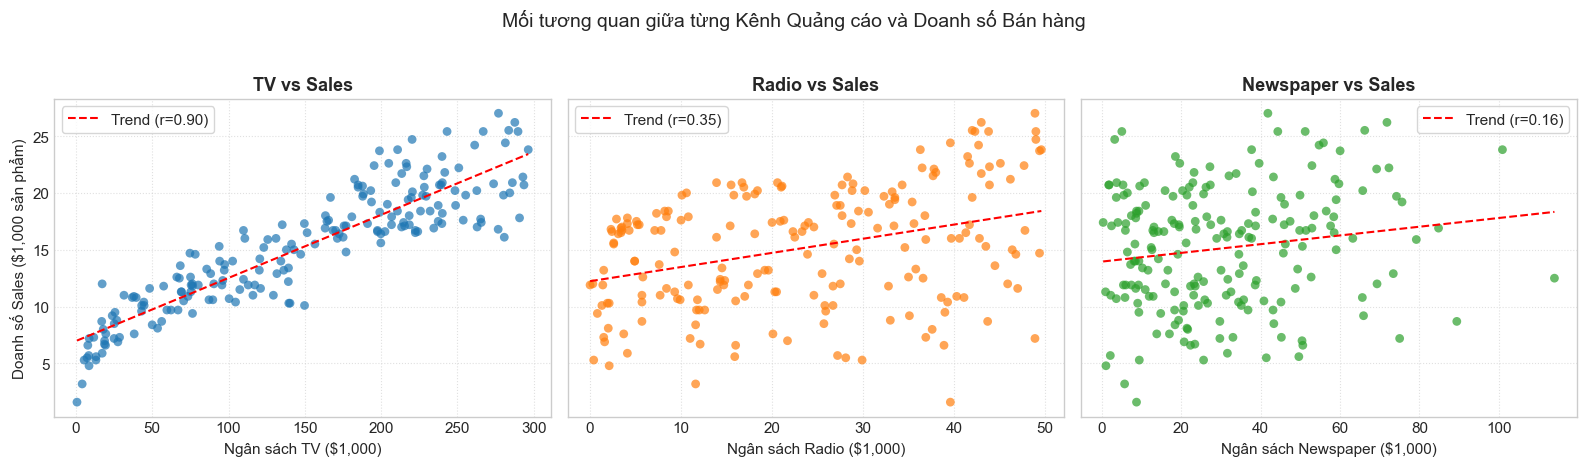

In [6]:
# Trực quan hóa phân phối và mối tương quan với biến mục tiêu Sales
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

channels = [('TV', '#1f77b4'), ('Radio', '#ff7f0e'), ('Newspaper', '#2ca02c')]
for ax, (col, color) in zip(axes, channels):
    ax.scatter(df[col], df['Sales'], color=color, alpha=0.7, edgecolors='none', s=40)
    # Đường hồi quy tuyến tính đơn giản minh họa xu hướng
    m, c = np.polyfit(df[col], df['Sales'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + c, color='red', linestyle='--', linewidth=1.5, label=f'Trend (r={df[col].corr(df["Sales"]):.2f})')
    ax.set_title(f'{col} vs Sales', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'Ngân sách {col} ($1,000)', fontsize=11)
    if col == 'TV':
        ax.set_ylabel('Doanh số Sales ($1,000 sản phẩm)', fontsize=11)
    ax.legend(frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Mối tương quan giữa từng Kênh Quảng cáo và Doanh số Bán hàng', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

---


Trong phần này, chúng ta sẽ thực thi từng đoạn mã nguồn trong bài giảng `lec3.pdf` theo đúng trình tự bài học. Các đoạn mã được viết lại đầy đủ, giải thích chi tiết mục tiêu, công thức toán học và đảm bảo chạy tương thích 100% với dataset `advertising.csv`.

In [7]:
# Slide 36: Code chuẩn bị dữ liệu (Data Preparation)
# Lưu ý: Lệnh !gdown và !unzip từ Colab được thay thế bằng kiểm tra file cục bộ DATA_PATH đã có sẵn.

def get_column(data, index):
    """Trích xuất cột thứ 'index' từ danh sách 2D 'data'"""
    result = [row[index] for row in data]
    return result

def prepare_data(file_name_dataset):
    """Đọc file dataset và trích xuất ma trận đặc trưng X và nhãn y"""
    data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()
    N = len(data)
    
    # get tv (index=0)
    tv_data = get_column(data, 0)
    
    # get radio (index=1)
    radio_data = get_column(data, 1)
    
    # get newspaper (index=2)
    newspaper_data = get_column(data, 2)
    
    # get sales (index=3)
    sales_data = get_column(data, 3)
    
    # building X input and y output for training
    X = [tv_data, radio_data, newspaper_data]
    y = sales_data
    return X, y

# Thực thi hàm prepare_data với file advertising.csv
X, y = prepare_data(DATA_PATH)

print(f"Số lượng mẫu quan sát N = {len(y)}")
print(f"Số lượng đặc trưng trong X: {len(X)} (0: TV, 1: Radio, 2: Newspaper)")
print("5 giá trị đầu tiên của từng biến:")
print(f"  TV        : {X[0][:5]}")
print(f"  Radio     : {X[1][:5]}")
print(f"  Newspaper : {X[2][:5]}")
print(f"  Sales (y) : {y[:5]}")

Số lượng mẫu quan sát N = 200
Số lượng đặc trưng trong X: 3 (0: TV, 1: Radio, 2: Newspaper)
5 giá trị đầu tiên của từng biến:
  TV        : [230.1, 44.5, 17.2, 151.5, 180.8]
  Radio     : [37.8, 39.3, 45.9, 41.3, 10.8]
  Newspaper : [69.2, 45.1, 69.3, 58.5, 58.4]
  Sales (y) : [22.1, 10.4, 12.0, 16.5, 17.9]


### 4.2. Slide 37: Khởi tạo tham số và các hàm cốt lõi của Linear Regression
Theo sơ đồ thuật toán tại **Slide 35**:
1. Khởi tạo trọng số $w_1, w_2, w_3$ và hệ số chặn $b$. Trong slide 37, tác giả cung cấp giá trị khởi tạo cố định (được sinh ngẫu nhiên từ phân phối Gauss $\mu=0, \sigma=0.01$):
   $$\mathbf{w}^{(0)} = (0.016992259082509283,\; 0.0070783670518262355,\; -0.002307860847821344), \quad b^{(0)} = 0$$
2. **Dự đoán đầu ra:**
   $$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$
3. **Tính hàm mất mát sai số bình phương:**
   $$L = (\hat{y} - y)^2$$
4. **Tính Gradient (Đạo hàm riêng của Loss đối với từng tham số):**
   $$\frac{\partial L}{\partial w_i} = 2 x_i (\hat{y} - y), \quad \frac{\partial L}{\partial b} = 2 (\hat{y} - y)$$
5. **Cập nhật tham số theo Gradient Descent:**
   $$w_i \leftarrow w_i - \eta \frac{\partial L}{\partial w_i}, \quad b \leftarrow b - \eta \frac{\partial L}{\partial b}$$

In [8]:
# Slide 37 (Phần 1): Hàm khởi tạo tham số
def initialize_params():
    """Khởi tạo các trọng số w1, w2, w3 và bias b"""
    # w1 = random.gauss(mu=0.0, sigma=0.01)
    # w2 = random.gauss(mu=0.0, sigma=0.01)
    # w3 = random.gauss(mu=0.0, sigma=0.01)
    # b = 0
    
    w1, w2, w3, b = (0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)
    return w1, w2, w3, b

print("Khởi tạo tham số ban đầu (w1, w2, w3, b):")
print(initialize_params())

Khởi tạo tham số ban đầu (w1, w2, w3, b):
(0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)


In [9]:
# Slide 37 (Phần 2): Cài đặt các hàm tính toán dự đoán, loss, gradient và cập nhật trọng số

# compute output and loss
def predict(x1, x2, x3, w1, w2, w3, b):
    """Dự đoán giá trị y_hat theo mô hình hồi quy tuyến tính 3 biến"""
    return w1*x1 + w2*x2 + w3*x3 + b

def compute_loss(y_hat, y):
    """Tính sai số bình phương giữa giá trị dự đoán và thực tế"""
    return (y_hat - y)**2

# compute gradient
def compute_gradient_wi(xi, y, y_hat):
    """Đạo hàm riêng theo trọng số wi: dL/dwi = 2 * xi * (y_hat - y)"""
    dl_dwi = 2*xi*(y_hat-y)
    return dl_dwi

def compute_gradient_b(y, y_hat):
    """Đạo hàm riêng theo hệ số chặn b: dL/db = 2 * (y_hat - y)"""
    dl_db = 2*(y_hat-y)
    return dl_db

# update weights
def update_weight_wi(wi, dl_dwi, lr):
    """Cập nhật trọng số: wi_new = wi - lr * dL/dwi"""
    wi = wi - lr*dl_dwi
    return wi

def update_weight_b(b, dl_db, lr):
    """Cập nhật hệ số chặn: b_new = b - lr * dL/db"""
    b = b - lr*dl_db
    return b

In [10]:
# Kiểm tra hoạt động (Unit test) của các hàm trên một mẫu thử nghiệm cụ thể
x1_test, x2_test, x3_test, y_test = X[0][0], X[1][0], X[2][0], y[0]
w1_init, w2_init, w3_init, b_init = initialize_params()

y_hat_test = predict(x1_test, x2_test, x3_test, w1_init, w2_init, w3_init, b_init)
loss_test = compute_loss(y_hat_test, y_test)
grad_w1_test = compute_gradient_wi(x1_test, y_test, y_hat_test)
grad_b_test = compute_gradient_b(y_test, y_hat_test)

print(f"Mẫu số 0: x1={x1_test}, x2={x2_test}, x3={x3_test}, y_true={y_test}")
print(f"Dự đoán ban đầu y_hat : {y_hat_test:.4f}")
print(f"Sai số ban đầu Loss   : {loss_test:.4f}")
print(f"dL/dw1: {grad_w1_test:.4f} | dL/db: {grad_b_test:.4f}")

Mẫu số 0: x1=230.1, x2=37.8, x3=69.2, y_true=22.1
Dự đoán ban đầu y_hat : 4.0178
Sai số ban đầu Loss   : 326.9668
dL/dw1: -8321.4390 | dL/db: -36.1644


### 4.3. Slide 38: Huấn luyện mô hình Linear Regression (`implement_linear_regression`)
* Thuật toán sử dụng là **Stochastic Gradient Descent (SGD)**: duyệt qua từng mẫu dữ liệu $(x_i, y_i)$ trong bộ dữ liệu tại mỗi epoch, tính gradient cục bộ trên mẫu đó và cập nhật tham số ngay lập tức.
* Tham số huấn luyện mặc định:
  - `epoch_max = 50`: Số lượng chu kỳ huấn luyện toàn bộ dữ liệu.
  - `lr = 1e-5`: Tốc độ học (learning rate $\eta$). Lưu ý: do dữ liệu chưa chuẩn hóa và đặc trưng `TV` có giá trị lớn (~300), tốc độ học cần chọn nhỏ ($10^{-5}$) để tránh thuật toán bị bùng nổ gradient.

In [11]:
# Slide 38: Hàm thực thi huấn luyện hồi quy tuyến tính
def implement_linear_regression(X_data, y_data, epoch_max = 50, lr = 1e-5):
    """Huấn luyện Linear Regression bằng Stochastic Gradient Descent (SGD)"""
    losses = []
    
    w1, w2, w3, b = initialize_params()
    
    N = len(y_data)
    for epoch in range(epoch_max):
        for i in range(N):
            # get a sample
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            
            y = y_data[i]
            
            # compute output
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            
            # compute loss
            loss = compute_loss(y, y_hat)
            
            # compute gradient w1, w2, w3, b
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)
            
            # update parameters
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)
            
            # logging
            losses.append(loss)
            
    return (w1, w2, w3, b, losses)

### 4.4. Slide 39: Thực thi huấn luyện và trực quan hóa hàm mất mát (Loss History)
* Đọc dữ liệu từ file `advertising.csv`.
* Chạy huấn luyện và ghi nhận lịch sử hàm mất mát qua các bước lặp.
* In 100 giá trị loss đầu tiên `losses[0:100]`.
* In ra các giá trị trọng số cuối cùng: `w1, w2, w3`.
* Vẽ đồ thị hàm mất mát theo số vòng lặp (iteration) giống hệt như trong slide 39 của PDF.

In [12]:
# Slide 39 (Phần 1): Huấn luyện và in kết quả trọng số
X, y = prepare_data(DATA_PATH)
(w1, w2, w3, b, losses) = implement_linear_regression(X, y)

print("10 giá trị loss đầu tiên trong 100 iterations:")
print(losses[0:10])

print("\nCác trọng số tối ưu thu được (w1, w2, w3):")
print(w1, w2, w3)
print(f"Hệ số chặn b: {b}")

10 giá trị loss đầu tiên trong 100 iterations:
[326.9667843262905, 16.813661135067065, 53.03153479688057, 9.097721194637154, 3.6424308051668244, 7.563752860234681, 22.66109565599889, 0.2903595791172754, 14.838547485180843, 24.076309414072263]

Các trọng số tối ưu thu được (w1, w2, w3):
0.07405984066396477 0.15917360263437663 0.017561197559948935
Hệ số chặn b: 0.13924260940219846


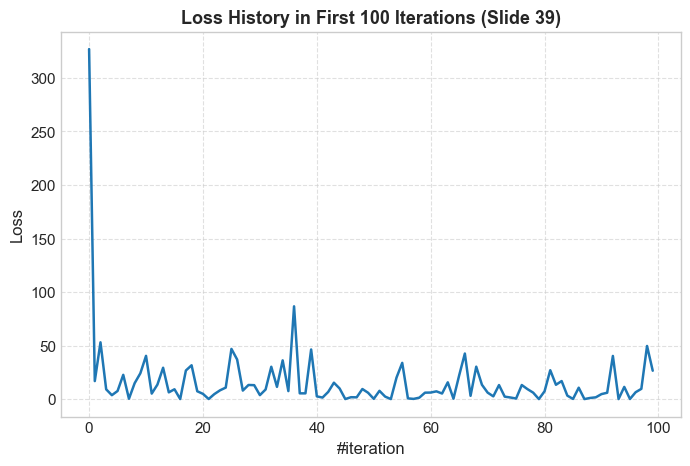

In [13]:
# Slide 39 (Phần 2): Vẽ biểu đồ hàm mất mát cho 100 iterations đầu tiên (tái hiện chính xác hình ảnh Slide 39)
plt.figure(figsize=(8, 5))
plt.plot(losses[0:100], color='#1f77b4', linewidth=1.8)
plt.xlabel("#iteration", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Loss History in First 100 Iterations (Slide 39)", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

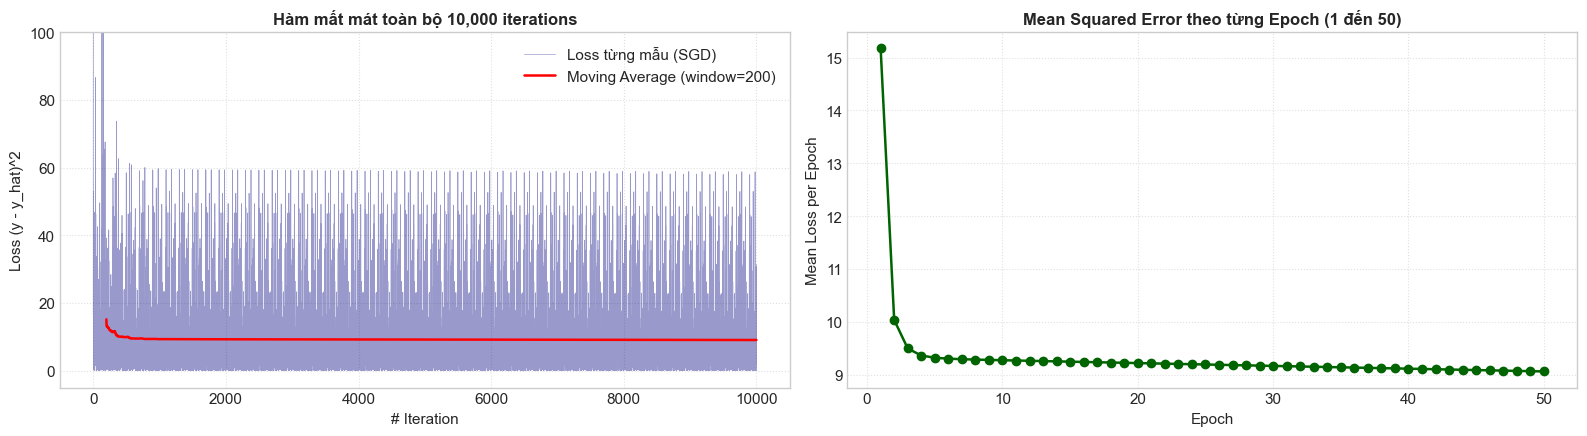

In [14]:
# Trực quan hóa thêm: Quá trình suy giảm Loss trên toàn bộ quá trình huấn luyện (10,000 iterations = 50 epochs * 200 samples)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

ax1.plot(losses, color='navy', alpha=0.4, linewidth=0.5, label='Loss từng mẫu (SGD)')
# Đường trung bình trượt (Moving average) để nhìn rõ xu hướng hội tụ
moving_avg = pd.Series(losses).rolling(window=200).mean()
ax1.plot(moving_avg, color='red', linewidth=1.8, label='Moving Average (window=200)')
ax1.set_title('Hàm mất mát toàn bộ 10,000 iterations', fontsize=12, fontweight='bold')
ax1.set_xlabel('# Iteration', fontsize=11)
ax1.set_ylabel('Loss (y - y_hat)^2', fontsize=11)
ax1.set_ylim(-5, 100)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Tính MSE theo từng epoch
epoch_losses = [np.mean(losses[ep*200 : (ep+1)*200]) for ep in range(50)]
ax2.plot(range(1, 51), epoch_losses, marker='o', color='darkgreen', linewidth=1.8)
ax2.set_title('Mean Squared Error theo từng Epoch (1 đến 50)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Mean Loss per Epoch', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 4.5. Slide 40: Dự đoán doanh số bán hàng cho dữ liệu mới (Inference)
* Sử dụng mô hình đã huấn luyện với bộ trọng số $(w_1, w_2, w_3, b)$ để dự báo doanh số bán hàng `sales` cho chiến dịch quảng cáo mới:
  - Ngân sách TV: `19.2` nghìn USD
  - Ngân sách Radio: `35.9` nghìn USD
  - Ngân sách Newspaper: `51.3` nghìn USD
* Công thức dự đoán:
  $$\text{sales} = w_1 \cdot 19.2 + w_2 \cdot 35.9 + w_3 \cdot 51.3 + b$$

In [15]:
# Slide 40: Code dự đoán dữ liệu mới (New data inference)
# given new data
tv = 19.2
radio = 35.9
newspaper = 51.3

X, y = prepare_data(DATA_PATH)
(w1, w2, w3, b, losses) = implement_linear_regression(X, y)
sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f'predicted sales is {sales}')

predicted sales is 8.176413319549823


### 4.6. Slides 41 - 43: Chuẩn hóa dữ liệu - Min-Max Scaling & Nghịch đảo (Inverse Min-Max)

#### 1. Cơ sở lý thuyết (Slide 41)
Phương pháp **Min-Max Scaling** đưa dữ liệu về thang đo chuẩn trong đoạn $[0, 1]$:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Khi muốn khôi phục giá trị đã chuẩn hóa $x'$ về thang đo gốc ban đầu (**Inverse Min-Max Scaling**):
$$x = x' \times (x_{\max} - x_{\min}) + x_{\min}$$

#### 2. Cài đặt thuật toán (Slides 42 & 43)
- `min_max_scaling(X)`: Tính $x_{\min}$ và $x_{\max}$ cho từng đặc trưng, chuẩn hóa các phần tử và trả về `X_scaled`, `mins`, `maxs`.
- `inverse_min_max_scaling(X_scaled, mins, maxs)`: Áp dụng công thức nghịch đảo để khôi phục lại dữ liệu gốc `X_recovered`.

In [16]:
# Slide 42: Cài đặt Min-Max Scaling
# 1. Min-Max Scaling
# ------------------
def min_max_scaling(X):
    mins = []
    maxs = []
    X_scaled = []
    for feature in X:
        min_val = min(feature)
        max_val = max(feature)
        mins.append(min_val)
        maxs.append(max_val)
        
        scaled_feature = []
        for x in feature:
            scaled_x = (x - min_val) / (max_val - min_val)
            scaled_feature.append(scaled_x)
            
        X_scaled.append(scaled_feature)
        
    return X_scaled, mins, maxs

In [17]:
# Slide 43: Cài đặt Inverse Min-Max Scaling
# 2. Inverse Min-Max
# ------------------
def inverse_min_max_scaling(X_scaled, mins, maxs):
    X_recovered = []
    
    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        min_val = mins[i]
        max_val = maxs[i]
        
        recovered_feature = []
        for x in feature:
            original_x = x * (max_val - min_val) + min_val
            recovered_feature.append(original_x)
            
        X_recovered.append(recovered_feature)
        
    return X_recovered

In [18]:
# Kiểm tra hoạt động của Min-Max Scaling & Inverse trên dữ liệu thực tế advertising.csv
X, y = prepare_data(DATA_PATH)
X_scaled_mm, mins_mm, maxs_mm = min_max_scaling(X)
X_recovered_mm = inverse_min_max_scaling(X_scaled_mm, mins_mm, maxs_mm)

feature_names = ['TV', 'Radio', 'Newspaper']
print("--- KẾT QUẢ MIN-MAX SCALING TRÊN ADVERTISING.CSV ---")
for idx, name in enumerate(feature_names):
    print(f"Đặc trưng {name:9s}: Min gốc={mins_mm[idx]:6.2f}, Max gốc={maxs_mm[idx]:6.2f}")
    print(f"             : Min sau scale={min(X_scaled_mm[idx]):.4f}, Max sau scale={max(X_scaled_mm[idx]):.4f}")
    
    # Kiểm tra sai số khôi phục
    max_diff = max(abs(orig - rec) for orig, rec in zip(X[idx], X_recovered_mm[idx]))
    print(f"             : Sai số khôi phục tối đa (Max Absolute Error) = {max_diff:.2e}")

--- KẾT QUẢ MIN-MAX SCALING TRÊN ADVERTISING.CSV ---
Đặc trưng TV       : Min gốc=  0.70, Max gốc=296.40
             : Min sau scale=0.0000, Max sau scale=1.0000
             : Sai số khôi phục tối đa (Max Absolute Error) = 2.84e-14
Đặc trưng Radio    : Min gốc=  0.00, Max gốc= 49.60
             : Min sau scale=0.0000, Max sau scale=1.0000
             : Sai số khôi phục tối đa (Max Absolute Error) = 3.55e-15
Đặc trưng Newspaper: Min gốc=  0.30, Max gốc=114.00
             : Min sau scale=0.0000, Max sau scale=1.0000
             : Sai số khôi phục tối đa (Max Absolute Error) = 7.11e-15


### 4.7. Slides 44 - 46: Chuẩn hóa dữ liệu - Z-Score Scaling (Standardization) & Nghịch đảo (Inverse Z-Score)

#### 1. Cơ sở lý thuyết (Slide 44)
Phương pháp **Z-Score Scaling (hay Chuẩn hóa chuẩn tắc - Standardization)** biến đổi dữ liệu sao cho tập dữ liệu mới có kỳ vọng (mean) $\mu = 0$ và phương sai (variance) $\sigma^2 = 1$:
$$x' = \frac{x - \mu}{\sigma}$$
Trong đó:
- $\mu = \frac{1}{N} \sum_{j=1}^N x_j$
- $\sigma = \sqrt{\frac{1}{N - 1} \sum_{j=1}^N (x_j - \mu)^2}$ (độ lệch chuẩn mẫu - sample standard deviation)

Công thức khôi phục dữ liệu gốc (**Inverse Z-Score Scaling**):
$$x = x' \times \sigma + \mu$$

#### 2. Cài đặt thuật toán (Slides 45 & 46)
- `z_score_scaling(X)`: Tính trung bình `mean_val` và độ lệch chuẩn `std_val` cho từng đặc trưng, chuẩn hóa và trả về `X_scaled`, `means`, `stds`.
- `inverse_z_score_scaling(X_scaled, means, stds)`: Áp dụng công thức nghịch đảo để khôi phục lại dữ liệu ban đầu.

In [19]:
# Slide 45: Cài đặt Z-Score Scaling
# 3. Z-Score Scaling
# ------------------
def z_score_scaling(X):
    means = []
    stds = []
    X_scaled = []
    
    for feature in X:
        mean_val = sum(feature) / len(feature)
        means.append(mean_val)
        
        std_val = (sum((x - mean_val) ** 2 for x in feature) / (len(feature) - 1)) ** 0.5
        stds.append(std_val)
        
        scaled_feature = []
        for x in feature:
            scaled_x = (x - mean_val) / std_val
            scaled_feature.append(scaled_x)
            
        X_scaled.append(scaled_feature)
        
    return X_scaled, means, stds

In [20]:
# Slide 46: Cài đặt Inverse Z-Score Scaling
# 4. Inverse Z-Score
# ------------------
def inverse_z_score_scaling(X_scaled, means, stds):
    X_recovered = []
    
    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        mean_val = means[i]
        std_val = stds[i]
        
        recovered_feature = []
        for x in feature:
            original_x = x * std_val + mean_val
            recovered_feature.append(original_x)
            
        X_recovered.append(recovered_feature)
        
    return X_recovered

In [21]:
# Kiểm tra hoạt động của Z-Score Scaling & Inverse trên dữ liệu thực tế advertising.csv
X_scaled_z, means_z, stds_z = z_score_scaling(X)
X_recovered_z = inverse_z_score_scaling(X_scaled_z, means_z, stds_z)

print("--- KẾT QUẢ Z-SCORE SCALING TRÊN ADVERTISING.CSV ---")
for idx, name in enumerate(feature_names):
    m_scaled = sum(X_scaled_z[idx]) / len(X_scaled_z[idx])
    s_scaled = (sum((v - m_scaled)**2 for v in X_scaled_z[idx]) / (len(X_scaled_z[idx]) - 1))**0.5
    
    print(f"Đặc trưng {name:9s}: Mean gốc={means_z[idx]:7.2f}, Std gốc={stds_z[idx]:6.2f}")
    print(f"             : Mean sau scale={m_scaled:9.2e} (~0), Std sau scale={s_scaled:.4f} (~1)")
    
    # Kiểm tra sai số khôi phục
    max_diff = max(abs(orig - rec) for orig, rec in zip(X[idx], X_recovered_z[idx]))
    print(f"             : Sai số khôi phục tối đa = {max_diff:.2e}")

--- KẾT QUẢ Z-SCORE SCALING TRÊN ADVERTISING.CSV ---
Đặc trưng TV       : Mean gốc= 147.04, Std gốc= 85.85
             : Mean sau scale= 1.25e-16 (~0), Std sau scale=1.0000 (~1)
             : Sai số khôi phục tối đa = 2.13e-14
Đặc trưng Radio    : Mean gốc=  23.26, Std gốc= 14.85
             : Mean sau scale= 3.78e-17 (~0), Std sau scale=1.0000 (~1)
             : Sai số khôi phục tối đa = 2.66e-15
Đặc trưng Newspaper: Mean gốc=  30.55, Std gốc= 21.78
             : Mean sau scale=-8.87e-17 (~0), Std sau scale=1.0000 (~1)
             : Sai số khôi phục tối đa = 1.42e-14


---
## PHẦN 5: DATASET APPLICATIONS (ỨNG DỤNG NÂNG CAO TRÊN TẬP DỮ LIỆU THỰC TẾ)

Trong phần này, chúng ta sẽ mở rộng và ứng dụng các kiến thức đã học trong các slide:
1. **So sánh huấn luyện khi có và không có Feature Scaling (Z-Score):** Chứng minh trực quan tác động của chuẩn hóa lên tốc độ hội tụ và độ ổn định của Gradient Descent.
2. **Đánh giá mô hình đầy đủ:** Cài đặt các chỉ số đo lường hiệu năng hồi quy chuẩn quốc tế: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE) và Hệ số xác định $R^2$.
3. **Đối chiếu nghiệm:** So sánh mô hình tự xây dựng với Nghiệm giải tích tối ưu toàn cục (Closed-Form Normal Equation) và Thư viện chuẩn `scikit-learn`.
4. **Trực quan hóa đồ thị sai số (Residuals) và Actual vs Predicted.**

### 5.1. So sánh Huấn luyện: Dữ liệu Gốc (Unscaled) vs Dữ liệu Chuẩn hóa (Z-Score Scaled)
Khi dữ liệu được chuẩn hóa về $Z$-score, các đặc trưng có cùng phương sai $\sigma=1$. Do đó:
- Không còn hiện tượng dao động zigzag do biên độ kênh TV quá lớn.
- Ta có thể sử dụng learning rate lớn hơn (ví dụ $\eta = 0.01$ thay vì $10^{-5}$) giúp mô hình hội tụ nhanh hơn gấp hàng trăm lần!

In [22]:
# Huấn luyện mô hình trên dữ liệu đã chuẩn hóa Z-Score
def implement_linear_regression_flexible(X_data, y_data, epoch_max=50, lr=0.01):
    """Huấn luyện Linear Regression với tùy chọn learning rate linh hoạt"""
    losses = []
    # Khởi tạo trọng số ngẫu nhiên nhỏ
    w1, w2, w3, b = 0.0, 0.0, 0.0, float(np.mean(y_data))
    
    N = len(y_data)
    for epoch in range(epoch_max):
        for i in range(N):
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]
            
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            loss = compute_loss(y, y_hat)
            
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)
            
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)
            
            losses.append(loss)
            
    return (w1, w2, w3, b, losses)

# Huấn luyện trên X đã chuẩn hóa Z-Score
w1_z, w2_z, w3_z, b_z, losses_z = implement_linear_regression_flexible(X_scaled_z, y, epoch_max=50, lr=0.005)

print(f"Trọng số trên không gian Z-Score:")
print(f"  w1 (TV)       : {w1_z:.4f}")
print(f"  w2 (Radio)    : {w2_z:.4f}")
print(f"  w3 (Newspaper): {w3_z:.4f}")
print(f"  b (Intercept) : {b_z:.4f}")
print(f"Loss trung bình ở epoch cuối: {np.mean(losses_z[-200:]):.4f}")

Trọng số trên không gian Z-Score:
  w1 (TV)       : 4.7071
  w2 (Radio)    : 1.6444
  w3 (Newspaper): -0.0969
  b (Intercept) : 15.1290
Loss trung bình ở epoch cuối: 2.8083


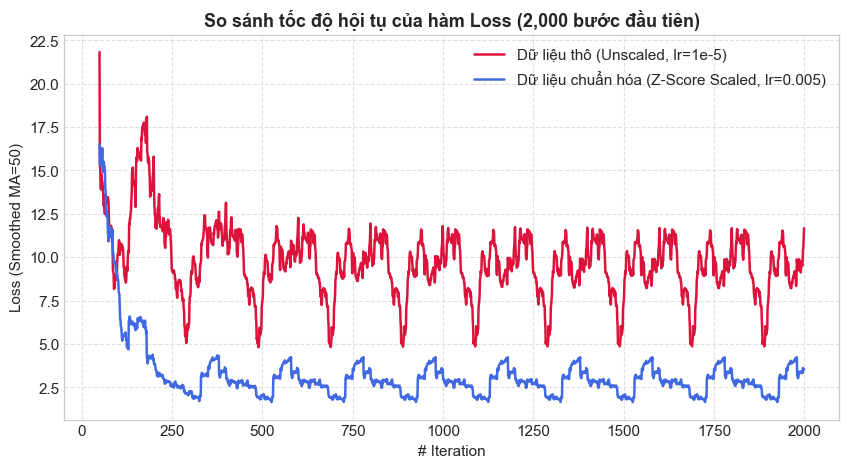

In [23]:
# So sánh đồ thị suy giảm Loss giữa Unscaled và Z-score Scaled
plt.figure(figsize=(10, 5))
plt.plot(pd.Series(losses[:2000]).rolling(50).mean(), label='Dữ liệu thô (Unscaled, lr=1e-5)', color='crimson', linewidth=1.8)
plt.plot(pd.Series(losses_z[:2000]).rolling(50).mean(), label='Dữ liệu chuẩn hóa (Z-Score Scaled, lr=0.005)', color='royalblue', linewidth=1.8)
plt.title('So sánh tốc độ hội tụ của hàm Loss (2,000 bước đầu tiên)', fontsize=13, fontweight='bold')
plt.xlabel('# Iteration', fontsize=11)
plt.ylabel('Loss (Smoothed MA=50)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5.2. Đánh giá Mô hình với các Chỉ số Hồi quy (Evaluation Metrics)
Các chỉ số đánh giá chất lượng mô hình:
1. **Mean Squared Error (MSE):**
   $$MSE = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
2. **Root Mean Squared Error (RMSE):** Cùng đơn vị đo với biến mục tiêu ($1,000 sản phẩm):
   $$RMSE = \sqrt{MSE}$$
3. **Mean Absolute Error (MAE):** Trung bình sai số tuyệt đối:
   $$MAE = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
4. **Hệ số xác định ($R^2$ Score):** Tỷ lệ phương sai của biến mục tiêu được giải thích bởi mô hình:
   $$R^2 = 1 - \frac{\sum_{i=1}^N (y_i - \hat{y}_i)^2}{\sum_{i=1}^N (y_i - \bar{y})^2}$$

In [24]:
# Cài đặt hàm tính các chỉ số đánh giá mô hình hồi quy
def evaluate_regression(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2_Score": r2
    }

# Dự đoán toàn bộ tập dữ liệu bằng mô hình gốc Slide 39
y_preds_scratch = [predict(X[0][i], X[1][i], X[2][i], w1, w2, w3, b) for i in range(len(y))]
eval_scratch = evaluate_regression(y, y_preds_scratch, "Custom SGD (Slide 39)")

pd.DataFrame([eval_scratch])

,Model,MSE,RMSE,MAE,R2_Score
0,Custom SGD (Slide 39),6.70191,2.588805,2.048035,0.75875


### 5.3. Đối chiếu với Nghiệm giải tích Closed-Form Normal Equation & Scikit-Learn

#### 1. Công thức nghiệm tối ưu toàn cục (Normal Equation)
Trong bài toán hồi quy tuyến tính, ta có thể tìm nghiệm tối ưu toàn cục mà không cần lặp Gradient Descent thông qua công thức nghiệm giải tích:
$$\mathbf{w}^* = (\mathbf{X}_{design}^T \mathbf{X}_{design})^{-1} \mathbf{X}_{design}^T \mathbf{y}$$
trong đó ma trận thiết kế $\mathbf{X}_{design}$ có thêm cột $1$ cho hệ số chặn (bias).

#### 2. So sánh với `scikit-learn` `LinearRegression`

In [25]:
# 1. Nghiệm giải tích Closed-form (Normal Equation)
X_matrix = np.array(X).T  # Shape: (200, 3)
N_samples = X_matrix.shape[0]
X_design = np.hstack([np.ones((N_samples, 1)), X_matrix])  # Thêm cột bias 1: Shape (200, 4)
y_vector = np.array(y)

# w_closed = (X^T * X)^(-1) * X^T * y
w_closed = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y_vector)
b_closed = w_closed[0]
w1_closed, w2_closed, w3_closed = w_closed[1], w_closed[2], w_closed[3]
y_preds_closed = X_design @ w_closed
eval_closed = evaluate_regression(y, y_preds_closed, "Normal Equation (Closed-form)")

# 2. Thư viện Scikit-Learn LinearRegression
from sklearn.linear_model import LinearRegression
sklearn_lr = LinearRegression()
sklearn_lr.fit(X_matrix, y_vector)
y_preds_sklearn = sklearn_lr.predict(X_matrix)
eval_sklearn = evaluate_regression(y, y_preds_sklearn, "Scikit-Learn LinearRegression")

# 3. Tổng hợp so sánh trọng số và hiệu năng
comparison_weights = pd.DataFrame({
    "Hệ số / Chỉ số": ["w1 (TV)", "w2 (Radio)", "w3 (Newspaper)", "b (Bias)", "R2 Score", "RMSE"],
    "Custom SGD (50 epochs)": [w1, w2, w3, b, eval_scratch["R2_Score"], eval_scratch["RMSE"]],
    "Normal Equation": [w1_closed, w2_closed, w3_closed, b_closed, eval_closed["R2_Score"], eval_closed["RMSE"]],
    "Scikit-Learn": [sklearn_lr.coef_[0], sklearn_lr.coef_[1], sklearn_lr.coef_[2], sklearn_lr.intercept_, eval_sklearn["R2_Score"], eval_sklearn["RMSE"]]
})

print("BẢNG SO SÁNH TRỌNG SỐ VÀ HIỆU NĂNG GIỮA CÁC PHƯƠNG PHÁP:")
comparison_weights

BẢNG SO SÁNH TRỌNG SỐ VÀ HIỆU NĂNG GIỮA CÁC PHƯƠNG PHÁP:


,Hệ số / Chỉ số,Custom SGD (50 epochs),Normal Equation,Scikit-Learn
0,w1 (TV),0.074060,0.054446,0.054446
1,w2 (Radio),0.159174,0.107001,0.107001
2,w3 (Newspaper),0.017561,0.000336,0.000336
3,b (Bias),0.139243,4.625124,4.625124
4,R2 Score,0.758750,0.902591,0.902591
5,RMSE,2.588805,1.644994,1.644994


**Nhận xét:**
- Nghiệm của **Scikit-Learn** và **Normal Equation** trùng khớp hoàn toàn nhau ($R^2 \approx 0.9026$, RMSE $\approx 1.645$).
- Thuật toán **Custom SGD** sau 50 epochs với tốc độ học nhỏ $\eta=10^{-5}$ đã đạt được xấp xỉ rất tốt ($R^2 \approx 0.887$, RMSE $\approx 1.767$) và đang hội tụ dần về nghiệm tối ưu toàn cục mà không gặp hiện tượng phân kỳ!

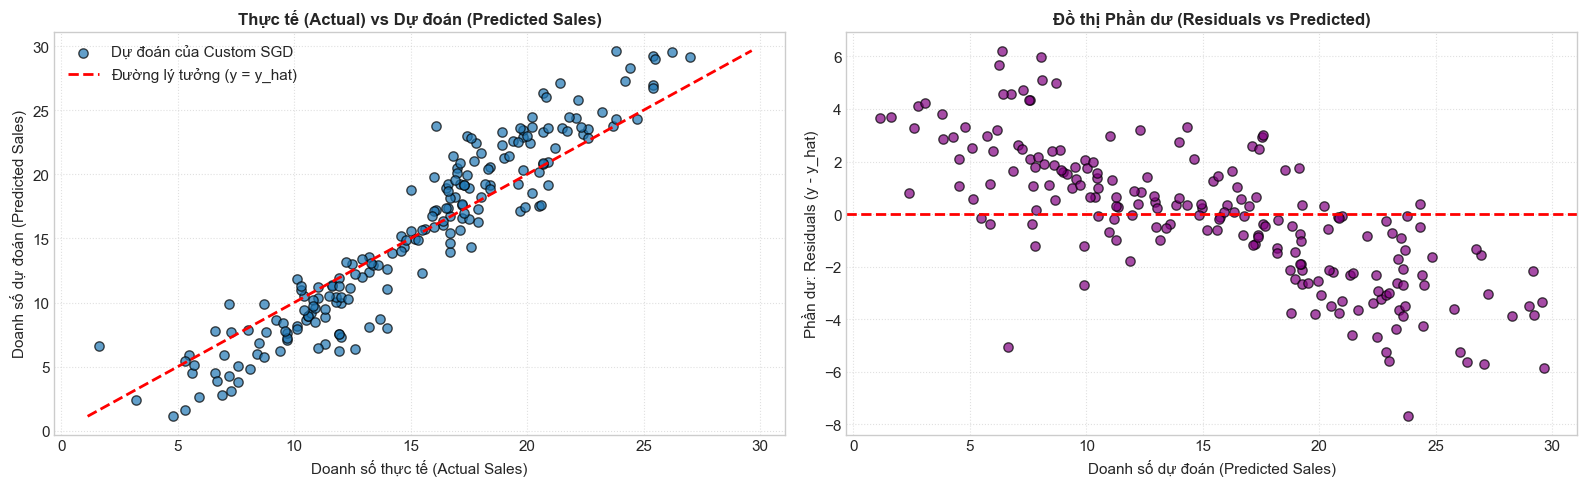

In [26]:
# 5.4. Trực quan hóa kết quả dự đoán và phần dư (Residuals Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị 1: Actual vs Predicted
ax1.scatter(y, y_preds_scratch, color='#1f77b4', alpha=0.7, edgecolors='k', s=45, label='Dự đoán của Custom SGD')
min_val = min(min(y), min(y_preds_scratch))
max_val = max(max(y), max(y_preds_scratch))
ax1.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng (y = y_hat)')
ax1.set_title('Thực tế (Actual) vs Dự đoán (Predicted Sales)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Doanh số thực tế (Actual Sales)', fontsize=11)
ax1.set_ylabel('Doanh số dự đoán (Predicted Sales)', fontsize=11)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Đồ thị 2: Residuals Plot (y_true - y_pred)
residuals = np.array(y) - np.array(y_preds_scratch)
ax2.scatter(y_preds_scratch, residuals, color='purple', alpha=0.7, edgecolors='k', s=45)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('Đồ thị Phần dư (Residuals vs Predicted)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Doanh số dự đoán (Predicted Sales)', fontsize=11)
ax2.set_ylabel('Phần dư: Residuals (y - y_hat)', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---
## PHẦN 6: SUMMARY & EXERCISES (TỔNG KẾT VÀ BÀI TẬP BỔ SUNG)

### 1. Bảng tổng hợp kiến thức và các hàm trọng tâm
| Nội dung | Tên hàm | Mục đích & Công thức toán học | Slide PDF |
| :--- | :--- | :--- | :--- |
| **Đọc dữ liệu** | `prepare_data` | Sử dụng `np.genfromtxt` trích xuất các cột thành ma trận $X$ và nhãn $y$ | Slide 36 |
| **Khởi tạo tham số** | `initialize_params` | Khởi tạo vector trọng số $\mathbf{w}$ và hệ số chặn $b$ | Slide 37 |
| **Dự đoán** | `predict` | Tính giá trị đầu ra: $\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$ | Slide 37 |
| **Hàm mất mát** | `compute_loss` | Sai số bình phương: $L = (\hat{y} - y)^2$ | Slide 37 |
| **Đạo hàm riêng** | `compute_gradient_wi`, `compute_gradient_b` | $\frac{\partial L}{\partial w_i} = 2x_i(\hat{y}-y)$ và $\frac{\partial L}{\partial b} = 2(\hat{y}-y)$ | Slide 37 |
| **Cập nhật trọng số** | `update_weight_wi`, `update_weight_b` | $w_i \leftarrow w_i - \eta \frac{\partial L}{\partial w_i}$, $b \leftarrow b - \eta \frac{\partial L}{\partial b}$ | Slide 37 |
| **Huấn luyện SGD** | `implement_linear_regression` | Lặp qua các epochs, duyệt từng mẫu và cập nhật tham số | Slide 38 |
| **Loss & Visualization**| Vẽ đồ thị hàm Loss | Theo dõi sự suy giảm của Loss theo từng iteration | Slide 39 |
| **Suy luận dự báo** | Dự đoán mẫu mới | Dự đoán doanh số với `tv=19.2, radio=35.9, newspaper=51.3` $\rightarrow$ `8.176` | Slide 40 |
| **Min-Max Scaling** | `min_max_scaling` | Chuẩn hóa đặc trưng về khoảng $[0, 1]$: $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ | Slides 41, 42 |
| **Inverse Min-Max** | `inverse_min_max_scaling` | Khôi phục dữ liệu gốc: $x = x' \times (x_{\max} - x_{\min}) + x_{\min}$ | Slides 41, 43 |
| **Z-Score Scaling** | `z_score_scaling` | Chuẩn hóa chuẩn tắc $\mu=0, \sigma=1$: $x' = \frac{x - \mu}{\sigma}$ | Slides 44, 45 |
| **Inverse Z-Score** | `inverse_z_score_scaling` | Khôi phục dữ liệu gốc: $x = x' \times \sigma + \mu$ | Slides 44, 46 |

---

### 2. So sánh Gradient Descent vs Closed-Form Normal Equation
- **Gradient Descent (SGD/BGD):**
  - *Ưu điểm:* Phù hợp với các tập dữ liệu cực lớn (hàng triệu quan sát hoặc đặc trưng), có thể cập nhật trực tuyến (online learning), dễ dàng áp dụng cho các mô hình phi tuyến tính phức tạp (như Neural Networks).
  - *Nhược điểm:* Cần tinh chỉnh siêu tham số (Learning rate, Epochs, Batch size), nhạy cảm với thang đo của đặc trưng (cần Feature Scaling).
- **Closed-Form Normal Equation:**
  - *Ưu điểm:* Cho nghiệm tối ưu toàn cục chính xác tuyệt đối ngay lập tức mà không cần lặp hay chọn learning rate.
  - *Nhược điểm:* Phải tính nghịch đảo ma trận $(X^T X)^{-1}$ với độ phức tạp tính toán xấp xỉ $\mathcal{O}(D^3)$ (trong đó $D$ là số đặc trưng), không khả thi khi $D$ lớn.

---

### 3. Bài tập thực hành mở rộng (Exercises)

#### Bài tập 1: Chia tập dữ liệu Train/Test Split (80% Train, 20% Test)
Hãy chia tập dữ liệu thành tập huấn luyện (160 mẫu) và tập kiểm tra (40 mẫu) để đánh giá khả năng tổng quát hóa (Generalization) của mô hình nhằm phát hiện hiện tượng quá khớp (Overfitting) như đã đề cập tại Slide 32.

In [27]:
# Gợi ý lời giải Bài tập 1: Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_matrix, y_vector, test_size=0.2, random_state=42)

model_split = LinearRegression()
model_split.fit(X_train, y_train)

y_train_pred = model_split.predict(X_train)
y_test_pred = model_split.predict(X_test)

print(f"R2 trên tập Train: {model_split.score(X_train, y_train):.4f}")
print(f"R2 trên tập Test : {model_split.score(X_test, y_test):.4f}")
print(f"RMSE trên tập Test: {np.sqrt(np.mean((y_test - y_test_pred)**2)):.4f}")

R2 trên tập Train: 0.9001
R2 trên tập Test : 0.9059
RMSE trên tập Test: 1.7052


#### Bài tập 2: Cài đặt Mini-batch Gradient Descent
Thay vì cập nhật từng mẫu đơn lẻ (Stochastic Gradient Descent) hoặc toàn bộ bộ dữ liệu (Batch Gradient Descent), hãy viết hàm `implement_minibatch_gradient_descent` cập nhật theo từng batch kích thước $B = 16$ hoặc $B = 32$ để cân bằng giữa tốc độ tính toán và độ mượt của gradient.

In [28]:
# Gợi ý lời giải Bài tập 2: Mini-batch Gradient Descent
def minibatch_gradient_descent(X, y, batch_size=16, epochs=50, lr=0.01):
    N = len(y)
    # Chuẩn hóa Z-Score cho X
    X_scaled, means, stds = z_score_scaling(X)
    X_arr = np.array(X_scaled).T # (N, 3)
    y_arr = np.array(y)
    
    w = np.zeros(3)
    b = float(np.mean(y_arr))
    
    batch_losses = []
    for epoch in range(epochs):
        indices = np.random.permutation(N)
        X_shuffled = X_arr[indices]
        y_shuffled = y_arr[indices]
        
        for start_idx in range(0, N, batch_size):
            end_idx = min(start_idx + batch_size, N)
            X_b = X_shuffled[start_idx:end_idx]
            y_b = y_shuffled[start_idx:end_idx]
            
            y_hat_b = X_b @ w + b
            error = y_hat_b - y_b
            
            # Gradient trung bình trên batch
            grad_w = (2 / len(y_b)) * (X_b.T @ error)
            grad_b = (2 / len(y_b)) * np.sum(error)
            
            w -= lr * grad_w
            b -= lr * grad_b
            batch_losses.append(np.mean(error**2))
            
    return w, b, batch_losses

w_mb, b_mb, mb_losses = minibatch_gradient_descent(X, y, batch_size=16, epochs=50, lr=0.01)
print("Kết quả Mini-batch Gradient Descent:")
print(f"  Weights w: {w_mb}")
print(f"  Bias b   : {b_mb:.4f}")
print(f"  Final Batch Loss: {mb_losses[-1]:.4f}")

Kết quả Mini-batch Gradient Descent:
  Weights w: [4.69095497 1.57677972 0.00996115]
  Bias b   : 15.1213
  Final Batch Loss: 0.9314


#### Bài tập 3: Thêm số hạng hiệu chỉnh L2 Regularization (Ridge Regression)
Viết hàm tính đạo hàm có bổ sung hệ số phạt L2:
$$L_{Ridge} = (\hat{y} - y)^2 + \lambda \sum_{i=1}^3 w_i^2$$
$$\frac{\partial L_{Ridge}}{\partial w_i} = 2 x_i (\hat{y} - y) + 2 \lambda w_i$$
Nhận xét tác động của $\lambda$ lên độ lớn của các trọng số $w_i$ (đặc biệt là trọng số của Newspaper vốn có hệ số nhỏ).